In [1]:
import os
if 'COLAB_GPU' in os.environ:
  print("GPU is enabled!")
else:
  print("GPU is not enabled!")

GPU is enabled!


In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.0 MB/s eta 0:00:00


In [3]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)


In [4]:
%pwd

'/content'

In [5]:
!mkdir RoadSignDetection

In [6]:
path = "/content/RoadSignDetection"
os.chdir("/content/RoadSignDetection")
%pwd

'/content/RoadSignDetection'

In [7]:
!pip install roboflow
from roboflow import Roboflow
rf = Roboflow(api_key="sipGaDeUgLg5fsyZ2X7F")
project = rf.workspace("selfdriving-car-qtywx").project("self-driving-cars-lfjou")
version = project.version(6)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 102.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Self-Driving-Cars-6 in yolov8:: 100%|██████████| 9950/9950 [00:01<00:00, 8131.40it/s]


In [14]:
os.chdir("/content/RoadSignDetection/Self-Driving-Cars-6")

In [9]:
!yolo task=detect mode=train model=yolov8n.pt data=data.yaml epochs=10 imgsz=640 batch=16

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, pl

In [15]:
!ls "/content/RoadSignDetection/Self-Driving-Cars-6/runs/detect/train"

args.yaml			 labels.jpg		val_batch0_pred.jpg
BoxF1_curve.png			 results.csv		val_batch1_labels.jpg
BoxP_curve.png			 results.png		val_batch1_pred.jpg
BoxPR_curve.png			 train_batch0.jpg	val_batch2_labels.jpg
BoxR_curve.png			 train_batch1.jpg	val_batch2_pred.jpg
confusion_matrix_normalized.png  train_batch2.jpg	weights
confusion_matrix.png		 val_batch0_labels.jpg


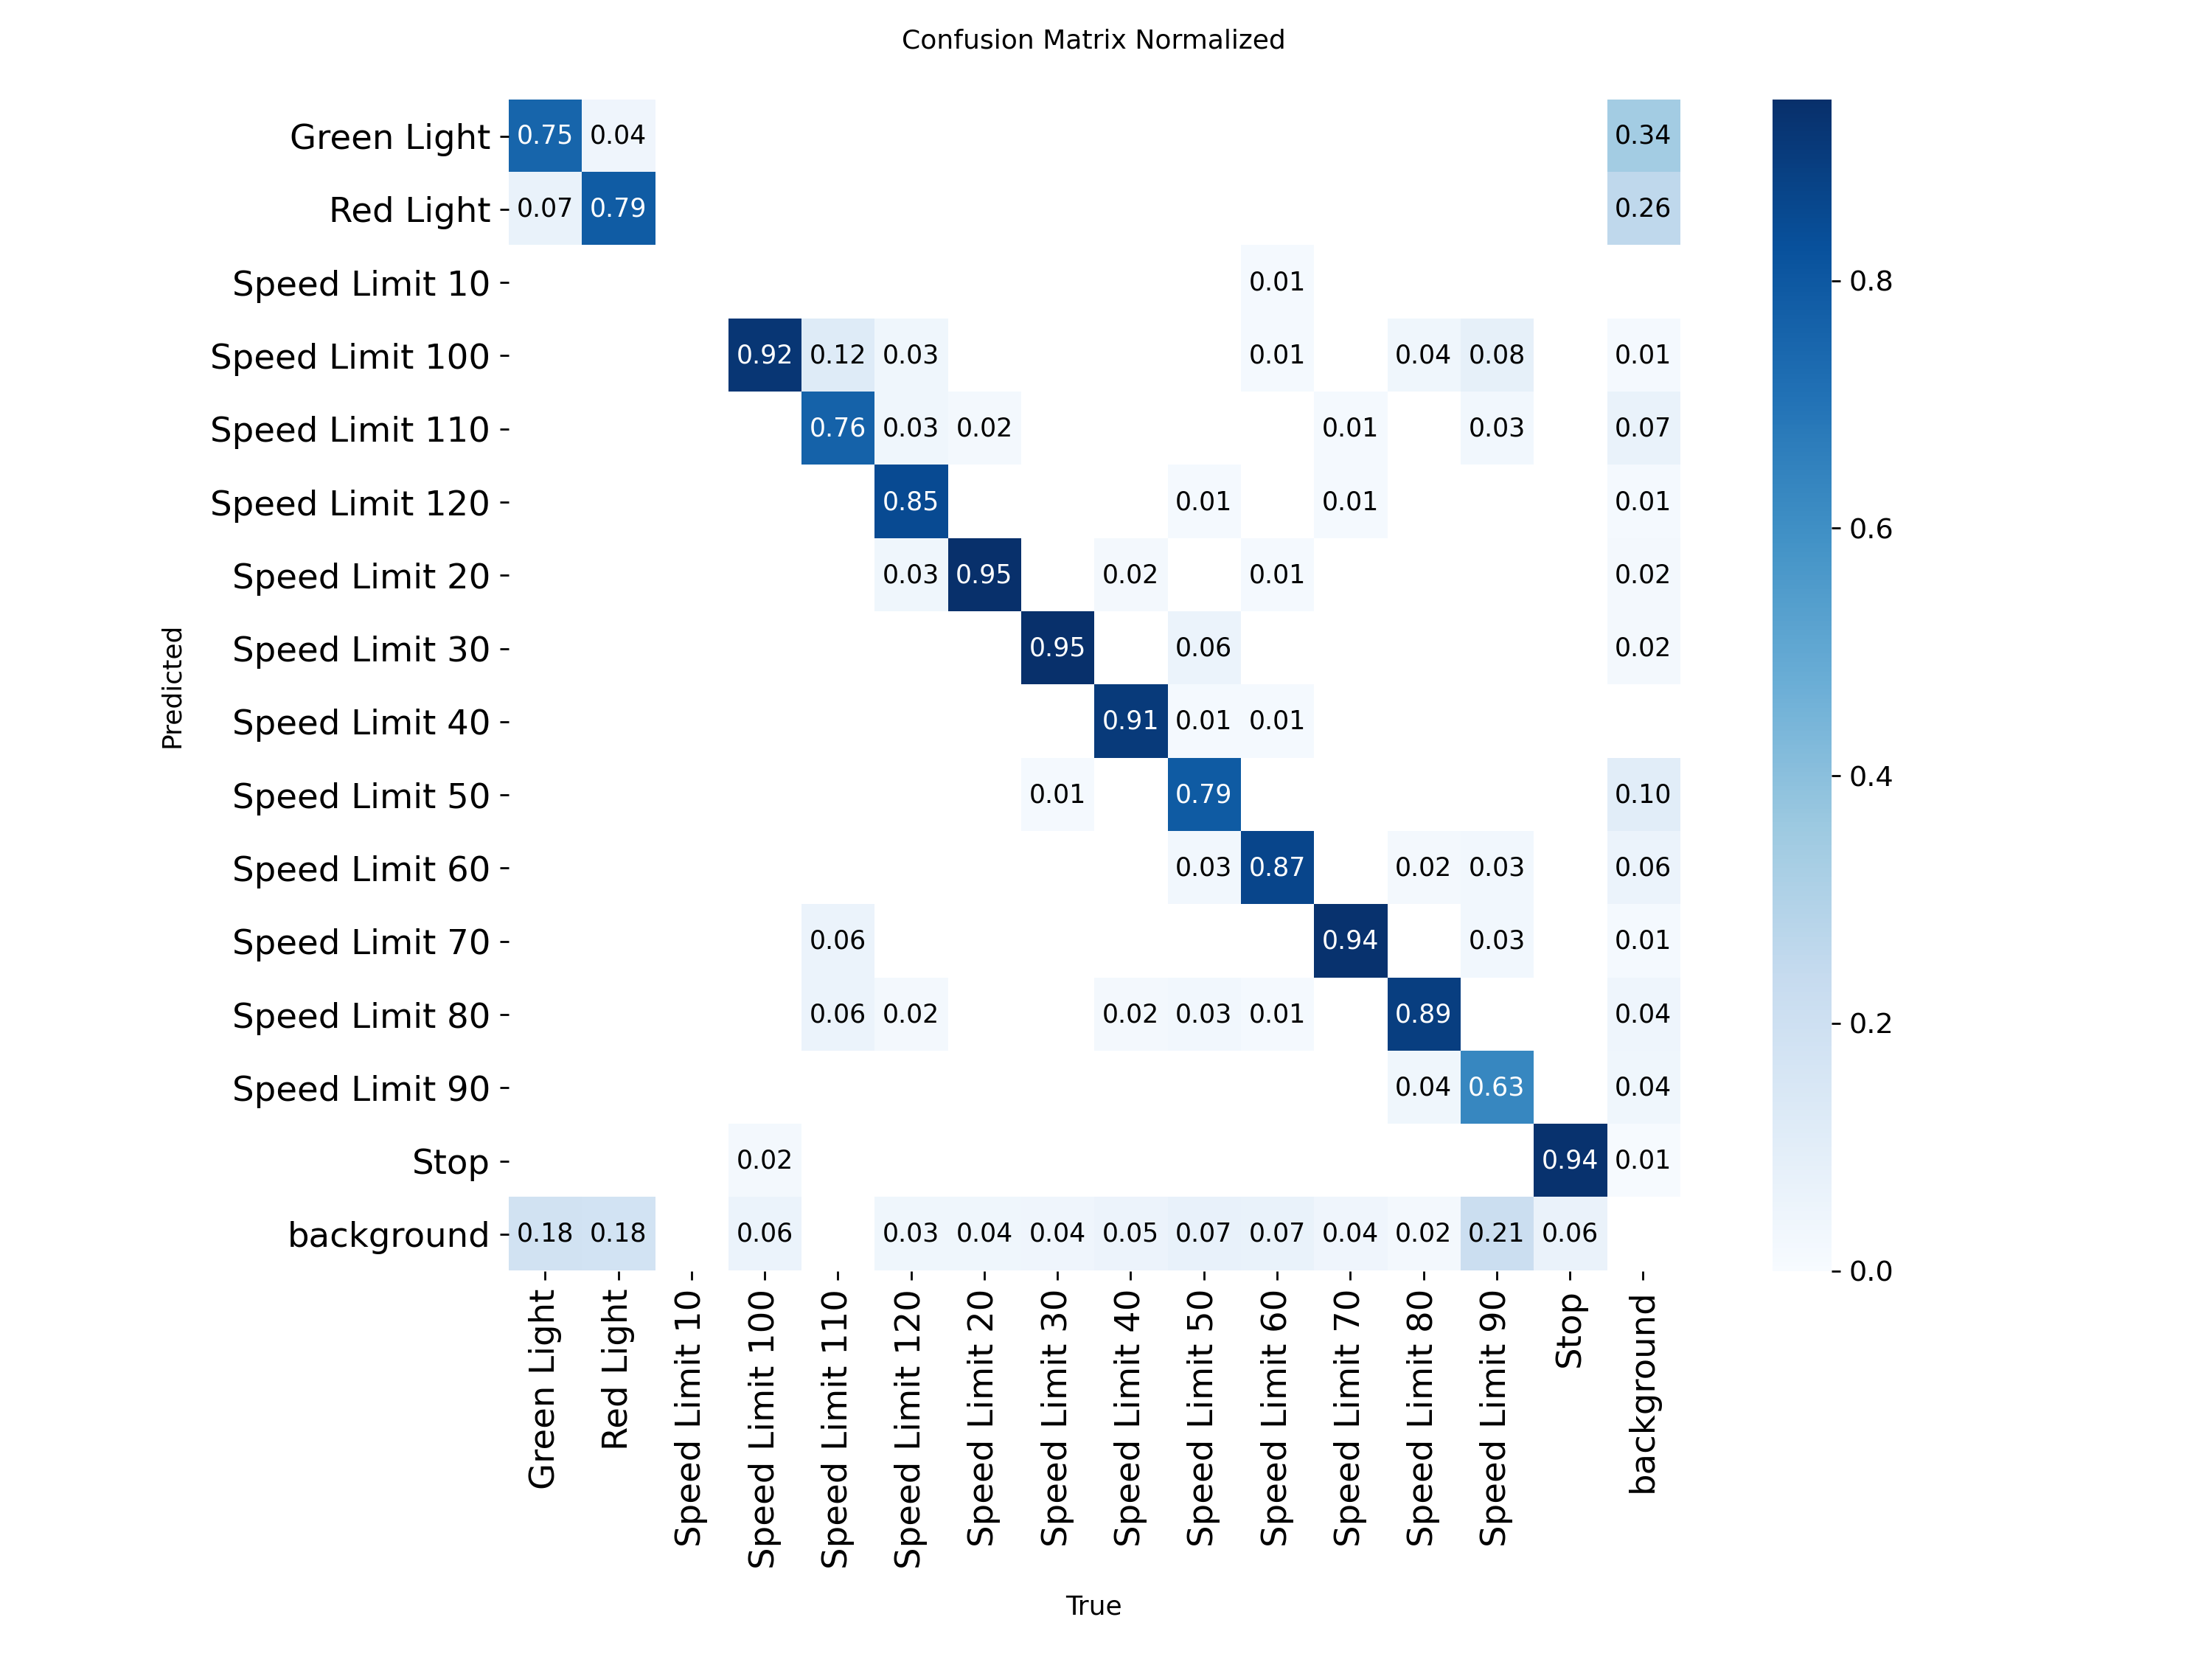

In [17]:
ResultData = "/content/RoadSignDetection/Self-Driving-Cars-6/runs/detect/train"
from IPython.display import Image, display
Image(filename = f'{ResultData}/confusion_matrix_normalized.png')

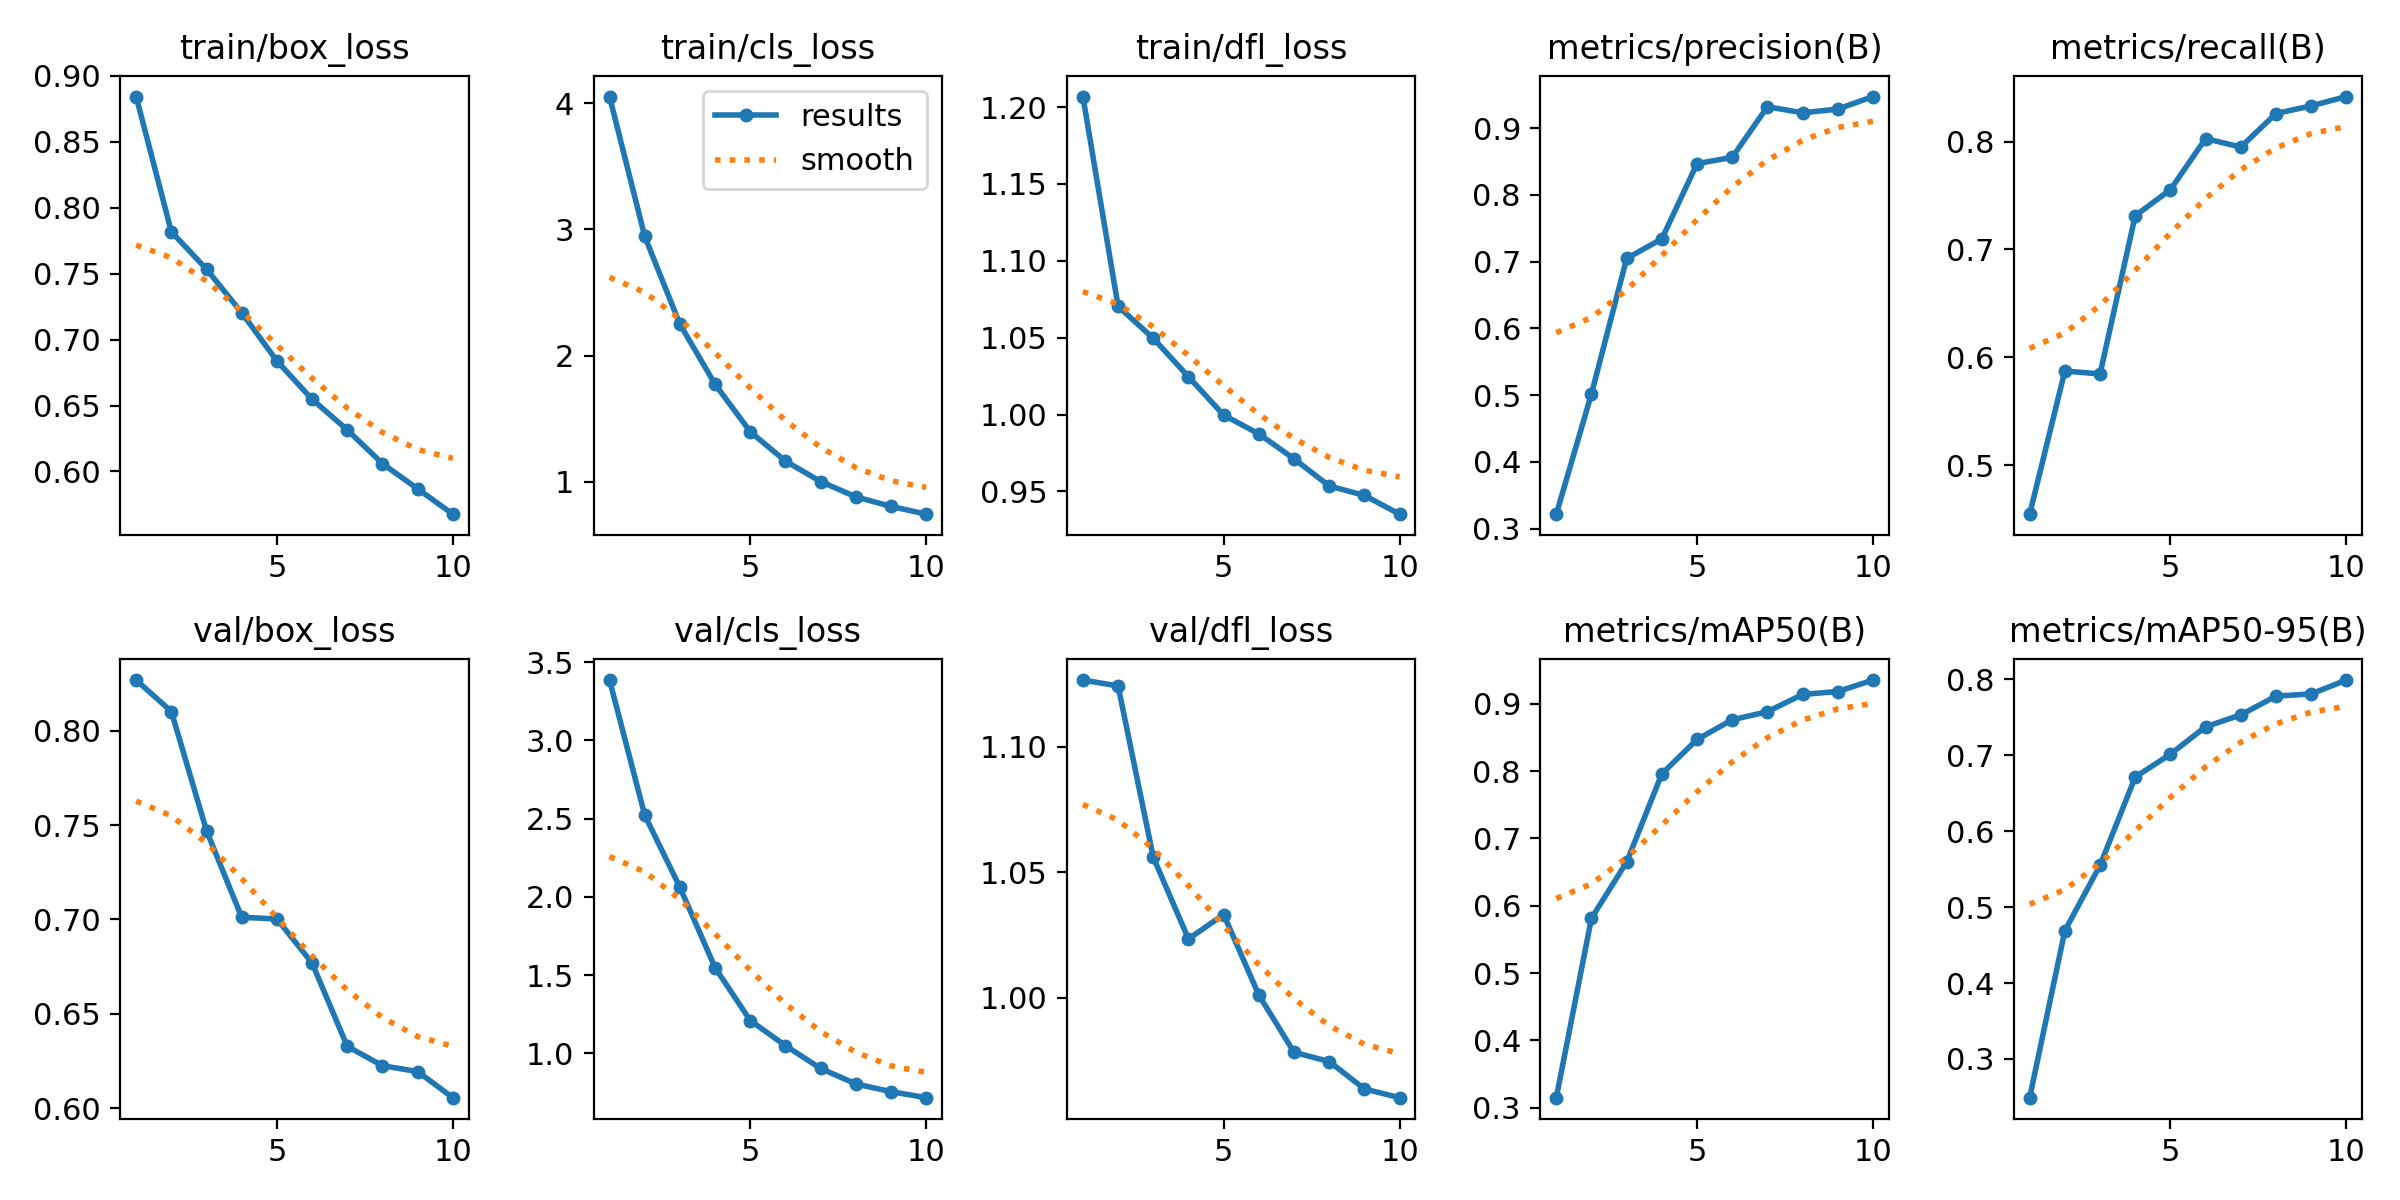

In [18]:
Image(filename = f'{ResultData}/results.png')

In [20]:
import pandas as pd

df = pd.read_csv("/content/RoadSignDetection/Self-Driving-Cars-6/runs/detect/train/results.csv")
df.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,65.5994,0.88438,4.05192,1.20680,0.32179,0.45440,0.31483,0.24905,0.82690,3.38521,1.12670,0.000175,0.000175,0.000175
1,2,124.6810,0.78186,2.94442,1.07037,0.50212,0.58725,0.58144,0.46889,0.81023,2.52261,1.12434,0.000315,0.000315,0.000315
2,3,184.4790,0.75340,2.24902,1.04956,0.70486,0.58450,0.66490,0.55497,0.74700,2.06174,1.05597,0.000421,0.000421,0.000421
3,4,245.0420,0.72042,1.77266,1.02456,0.73420,0.73131,0.79593,0.67116,0.70116,1.54794,1.02342,0.000370,0.000370,0.000370
4,5,303.3950,0.68384,1.39673,0.99965,0.84689,0.75549,0.84698,0.70130,0.70029,1.21018,1.03316,0.000318,0.000318,0.000318


In [21]:
%pwd

'/content/RoadSignDetection/Self-Driving-Cars-6'

In [22]:
os.chdir("/content")

In [23]:
%pwd

'/content'

In [24]:
!mkdir ManualTestingData

In [25]:
os.chdir("/content/ManualTestingData")

In [26]:
URL = "https://drive.google.com/file/d/1C_y4trwDvLdozu9COYh9FfbkGVASoNSY/view?usp=drive_link"
id = "1C_y4trwDvLdozu9COYh9FfbkGVASoNSY"
!wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=1C_y4trwDvLdozu9COYh9FfbkGVASoNSY' -O inputvideo1.mp4

--2026-06-20 22:34:13--  https://docs.google.com/uc?export=download&id=1C_y4trwDvLdozu9COYh9FfbkGVASoNSY
Resolving docs.google.com (docs.google.com)... 172.253.117.101, 172.253.117.102, 172.253.117.113, ...
Connecting to docs.google.com (docs.google.com)|172.253.117.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1C_y4trwDvLdozu9COYh9FfbkGVASoNSY&export=download [following]
--2026-06-20 22:34:13--  https://drive.usercontent.google.com/download?id=1C_y4trwDvLdozu9COYh9FfbkGVASoNSY&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.142.132, 2607:f8b0:400e:c08::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.142.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1516907 (1.4M) [video/mp4]
Saving to: ‘inputvideo1.mp4’

inputvideo1.mp4     100%[===================>]   1.45M  --.-KB/s    in 0.008s  

In [27]:
WeightsPath = "/content/RoadSignDetection/Self-Driving-Cars-6/runs/detect/train/weights"
!yolo task=detect mode=predict model={WeightsPath}/best.pt conf=0.25 source='inputvideo1.mp4'

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,008,573 parameters, 0 gradients, 8.1 GFLOPs

video 1/1 (frame 1/1152) /content/ManualTestingData/inputvideo1.mp4: 384x640 1 Green Light, 1 Speed Limit 80, 67.1ms
video 1/1 (frame 2/1152) /content/ManualTestingData/inputvideo1.mp4: 384x640 1 Green Light, 1 Speed Limit 80, 10.0ms
video 1/1 (frame 3/1152) /content/ManualTestingData/inputvideo1.mp4: 384x640 1 Green Light, 1 Speed Limit 80, 9.6ms
video 1/1 (frame 4/1152) /content/ManualTestingData/inputvideo1.mp4: 384x640 1 Green Light, 1 Speed Limit 80, 10.3ms
video 1/1 (frame 5/1152) /content/ManualTestingData/inputvideo1.mp4: 384x640 1 Green Light, 1 Speed Limit 80, 7.4ms
video 1/1 (frame 6/1152) /content/ManualTestingData/inputvideo1.mp4: 384x640 1 Green Light, 1 Speed Limit 80, 7.1ms
video 1/1 (frame 7/1152) /content/ManualTestingData/inputvideo1.mp4: 384x640 1 Green Light, 1 Speed Limit 80, 7.7ms
video 1/1 (frame 8/11

In [28]:
URL_Photo = "https://drive.google.com/file/d/1IrQJ37rrRz1rnD8LmUYXvfnQPAMvPwuU/view?usp=drive_link"
id = "1IrQJ37rrRz1rnD8LmUYXvfnQPAMvPwuU"
!wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=1IrQJ37rrRz1rnD8LmUYXvfnQPAMvPwuU' -O inputimage1.jpg

--2026-06-20 22:41:06--  https://docs.google.com/uc?export=download&id=1IrQJ37rrRz1rnD8LmUYXvfnQPAMvPwuU
Resolving docs.google.com (docs.google.com)... 74.125.142.102, 74.125.142.113, 74.125.142.138, ...
Connecting to docs.google.com (docs.google.com)|74.125.142.102|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1IrQJ37rrRz1rnD8LmUYXvfnQPAMvPwuU&export=download [following]
--2026-06-20 22:41:07--  https://drive.usercontent.google.com/download?id=1IrQJ37rrRz1rnD8LmUYXvfnQPAMvPwuU&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.142.132, 2607:f8b0:400e:c08::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.142.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17320581 (17M) [image/jpeg]
Saving to: ‘inputimage1.jpg’

inputimage1.jpg     100%[===================>]  16.52M  --.-KB/s    in 0.1s    

2

In [29]:
!yolo task=detect mode=predict model={WeightsPath}/best.pt conf=0.25 source='inputimage1.jpg' save= True

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,008,573 parameters, 0 gradients, 8.1 GFLOPs

image 1/1 /content/ManualTestingData/inputimage1.jpg: 448x640 1 Stop, 42.4ms
Speed: 4.3ms preprocess, 42.4ms inference, 16.5ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/ManualTestingData/runs/detect/predict-2
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [30]:
from google.colab import files
files.download('/content/ManualTestingData/runs/detect/predict/inputvideo1.avi')
files.download('/content/ManualTestingData/runs/detect/predict-2/inputimage1.jpg')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>